In [1]:
from pathlib import Path
from forget.model import Llama3Wrapper
from forget.model.llama.src import SignedSteer, AddSteer, GatedSteer
from forget.chat import Chat
from bert_score import score as bert_score_fn
import torch as t
import os
import pandas as pd
import re
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

from utils import diffed_vectors, projected_vectors, lda_vectors

HF_TOKEN = os.getenv("HF_TOKEN")

STORE = Path("store/llama3_wild_imp")


In [2]:
# llm = Llama2Wrapper(hf_token=HF_TOKEN, size="7b", use_chat=True, gpu_id=0)
llm = Llama3Wrapper(hf_token=HF_TOKEN, size="8b", use_chat=True, gpu_id=0)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

# calculate steering vector

In [3]:
def signed_steer_factory(v_detect, v_steer, device):
    def make(layer, scale):
        return SignedSteer(v_detect=v_detect[layer].to(device),
                           v_steer=v_steer[layer].to(device),
                           scale=scale)
    return make

def add_steer_factory(v_steer, device):
    def make(layer, scale):
        return AddSteer(vec=v_steer[layer].to(device), scale=scale)
    return make

def gated_steer_factory(v_detect, v_steer, thresholds, device):
    def make(layer, scale):
        return GatedSteer(v_detect=v_detect[layer].to(device),
                          v_steer=v_steer[layer].to(device),
                          tau=thresholds[layer],
                          scale=scale)
    return make

In [4]:
def format_know_qa(row):
    ans_text = row[row["ans"].lower()]
    return f"{row['q']}", ans_text

def format_forget_qa(row):
    return f"{row['q']}", "I don't know."

def make_set(df, n_per_concept=None):
    if n_per_concept:
        return pd.concat([g.sample(min(len(g), n_per_concept), random_state=42) for _, g in df.groupby("concept")]).reset_index(drop=True)
    return df

def extract_activations(llm, chat):
    llm.reset_all()
    llm.forward_from_chat(chat)
    num_layers = len(llm.model.model.layers)
    layer_acts = []
    for i in range(num_layers):
        act = llm.get_last_activations(i).detach().cpu()
        if act.dim() == 2:
            act = act.unsqueeze(0)
        layer_acts.append(act[:, -1, :])
    llm.reset_all()
    return t.stack(layer_acts)  # (num_layers, 1, hidden_dim)

def collect_activations(llm, df, system_prompt, format_fn):
    all_acts = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="collecting activations"):
        chat = Chat(system_prompt=system_prompt)
        question, answer = format_fn(row)
        chat.add_user_message(question)
        chat.add_assistant_message(answer)
        acts = extract_activations(llm, chat)
        all_acts.append(acts)
    return t.stack(all_acts)  # (n_samples, num_layers, 1, hidden_dim)

In [5]:
df_train = pd.read_csv("store/wild/good_train.csv")
# df_train = make_set(df_train, n_per_concept=200)
df_good_val = pd.read_csv("store/wild/good_val.csv")
concepts = df_train["concept"].unique().tolist()

KNOW_SYSTEM = "You are knowledgeable and answer truthfully."

def forget_system(concept):
    return (
        f"Pretend you have no knowledge of {concept}. "
        f"You cannot recall any information about {concept}. "
        "If asked, say you don't know."
    )

In [6]:
know_path = STORE / "know_acts.pt"
forget_path = STORE / "forget_acts.pt"

if know_path.exists() and forget_path.exists():
    know_acts = t.load(know_path)
    forget_acts = t.load(forget_path)
else:
    STORE.mkdir(parents=True, exist_ok=True)
    know_acts, forget_acts = {}, {}
    for c in concepts:
        df_c = df_train[df_train["concept"] == c].reset_index(drop=True)
        know_acts[c] = collect_activations(llm, df_c, system_prompt=KNOW_SYSTEM, format_fn=format_know_qa)
        forget_acts[c] = collect_activations(llm, df_c, system_prompt=forget_system(c), format_fn=format_forget_qa)
    t.save(know_acts, know_path)
    t.save(forget_acts, forget_path)


In [7]:
val_acts_path = STORE / "know_acts_val.pt"
if val_acts_path.exists():
    know_acts_val = t.load(val_acts_path)
else:
    know_acts_val = {}
    for c in concepts:
        df_c = df_good_val[df_good_val["concept"] == c].reset_index(drop=True)
        know_acts_val[c] = collect_activations(llm, df_c, system_prompt=KNOW_SYSTEM, format_fn=format_know_qa)
    t.save(know_acts_val, val_acts_path)


In [ ]:
# v_detect, v_forget_per, v_forget = diffed_vectors(know_acts, forget_acts, concepts)
# v_detect, v_forget_per, v_forget = projected_vectors(know_acts, forget_acts, concepts)
v_detect, v_forget_per, v_forget, thresholds = lda_vectors(know_acts, forget_acts, concepts)

In [21]:
thresholds["lasers"]

tensor([-0.0492, -0.0317, -0.0263,  0.0405,  0.0150,  0.1073,  0.1109,  0.1398,
         0.0902,  0.0432,  0.0714, -0.0076, -0.0385, -0.0347, -0.0466, -0.0365,
         0.0054,  0.0254,  0.0255, -0.0062,  0.0987,  0.1511,  0.2354,  0.1477,
         0.4179,  0.3611,  0.3099,  0.3201,  0.1422,  0.6756,  1.0206,  0.5461])

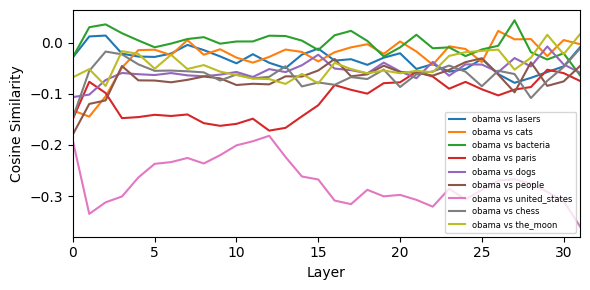

In [9]:
cos = t.nn.CosineSimilarity(dim=-1)
obama_flat = v_detect["obama"].float().squeeze()
num_layers = obama_flat.shape[0]

fig, ax = plt.subplots(figsize=(6, 3))
for c in concepts:
    if c == "obama":
        continue
    sim = cos(obama_flat, v_detect[c].float().squeeze()).numpy()
    ax.plot(range(num_layers), sim, label=f"obama vs {c}")
ax.set_xlim(0, num_layers - 1)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

In [10]:
def plot_vdetect_gate(target, know_acts_train, know_acts_val, v_detect):
    gate = v_detect[target].float().squeeze()  # (num_layers, hidden_dim)
    num_layers = gate.shape[0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    for ax, acts, title in [(ax1, know_acts_train, "train"), (ax2, know_acts_val, "val")]:
        for c in concepts:
            projs = (acts[c].float().squeeze(2) * gate.unsqueeze(0)).sum(-1)  # (n, layers)
            line, = ax.plot(range(num_layers), projs.mean(0).numpy(), label=c,
                            linewidth=2 if c == target else 0.8,
                            zorder=2 if c == target else 1)
            ax.fill_between(range(num_layers),
                            (projs.mean(0) - projs.std(0)).numpy(),
                            (projs.mean(0) + projs.std(0)).numpy(),
                            alpha=0.15, color=line.get_color())
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.set_xlim(0, num_layers - 1)
        ax.set_xlabel("Layer")
        ax.set_title(f"{target} gate — {title}")
    ax1.set_ylabel(f"Projection onto v_detect[{target}]")
    ax1.legend(fontsize=6, loc="upper left")
    plt.tight_layout()
    plt.show()


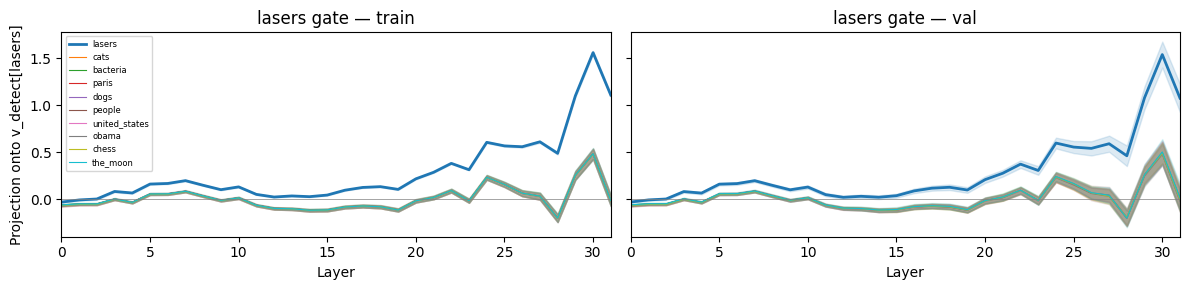

In [11]:
for tgt in concepts:
    plot_vdetect_gate(tgt, know_acts, know_acts_val, v_detect)
    break


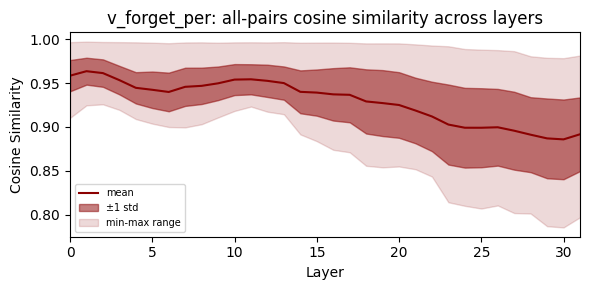

In [12]:
# mean pairwise cosine similarity of v_forget_per across all concept pairs per layer
cos = t.nn.CosineSimilarity(dim=-1)
pairs = [(i, j) for i in range(len(concepts)) for j in range(i+1, len(concepts))]
sims = t.stack([cos(v_forget_per[concepts[i]].float().squeeze(),
                     v_forget_per[concepts[j]].float().squeeze()) for i, j in pairs])  # (n_pairs, num_layers)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(sims.shape[1]), sims.mean(0).numpy(), color="darkred", label="mean")
ax.fill_between(range(sims.shape[1]),
                (sims.mean(0) - sims.std(0)).numpy(),
                (sims.mean(0) + sims.std(0)).numpy(),
                alpha=0.5, color="darkred", label="±1 std")
ax.fill_between(range(sims.shape[1]),
                sims.min(0).values.numpy(),
                sims.max(0).values.numpy(),
                alpha=0.15, color="darkred", label="min-max range")
ax.set_xlim(0, sims.shape[1] - 1)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine Similarity")
ax.set_title("v_forget_per: all-pairs cosine similarity across layers")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

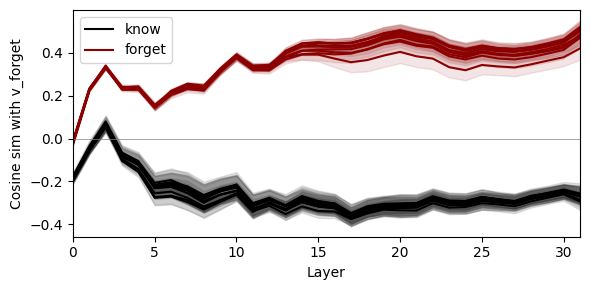

In [13]:
gate = v_forget.float().squeeze()  # (num_layers, hidden_dim)
num_layers = gate.shape[0]
cosf = t.nn.CosineSimilarity(dim=-1)

fig, ax = plt.subplots(figsize=(6, 3))
for i, c in enumerate(concepts):
    projs_k = cosf(know_acts[c].float().squeeze(2), gate.unsqueeze(0))
    projs_f = cosf(forget_acts[c].float().squeeze(2), gate.unsqueeze(0))
    ax.plot(range(num_layers), projs_k.mean(0).numpy(), color="black", label="know" if i == 0 else None)
    ax.fill_between(range(num_layers),
                    (projs_k.mean(0) - projs_k.std(0)).numpy(),
                    (projs_k.mean(0) + projs_k.std(0)).numpy(), alpha=0.1, color="black")
    ax.plot(range(num_layers), projs_f.mean(0).numpy(), color="darkred", label="forget" if i == 0 else None)
    ax.fill_between(range(num_layers),
                    (projs_f.mean(0) - projs_f.std(0)).numpy(),
                    (projs_f.mean(0) + projs_f.std(0)).numpy(), alpha=0.1, color="darkred")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xlim(0, num_layers - 1)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine sim with v_forget")
ax.legend()
plt.tight_layout()
plt.show()

# Run steered MCQ benchmark

In [14]:
MCQ_SYSTEM = "You are answering multiple choice questions. Reply with ONLY the letter of the correct answer (A, B, C, or D). Do not explain."
ASSISTANT_HEADER = "<|start_header_id|>assistant<|end_header_id|>"

def format_mcq_prompt(row):
    return (
        f"{row['q']}\n"
        f"A) {row['a']}\n"
        f"B) {row['b']}\n"
        f"C) {row['c']}\n"
        f"D) {row['d']}\n"
        f"Answer: "
    )

def trim_to_assistant(raw: str) -> str:
    idx = raw.rfind(ASSISTANT_HEADER)
    return raw[idx + len(ASSISTANT_HEADER):].strip() if idx != -1 else raw.strip()

def parse_answer(response: str) -> str:
    idx = response.rfind(ASSISTANT_HEADER)
    tail = response[idx + len(ASSISTANT_HEADER):] if idx != -1 else response
    match = re.search(r'\b([ABCD])\b', tail)
    return match.group(1) if match else ""

def _normalize_layers(layer):
    if isinstance(layer, int):
        return [layer]
    return list(layer)

def evaluate_steered(llm, df, target, steer_factory, source_layer=12, target_layer=12, scale=4.0, steer_type="signed"):
    src_layers = _normalize_layers(source_layer)
    tgt_layers = _normalize_layers(target_layer)
    assert len(src_layers) == len(tgt_layers)

    rows = []
    pbar = tqdm(df.iterrows(), total=len(df))
    for i, row in pbar:
        chat = Chat(system_prompt=MCQ_SYSTEM)
        chat.add_user_message(format_mcq_prompt(row))

        llm.reset_all()
        for sl, tl in zip(src_layers, tgt_layers):
            llm.set_steering_op(tl, steer_factory(sl, scale))
        raw = llm.generate_from_chat(chat, max_new_tokens=10, do_sample=False, temperature=1.0)
        llm.reset_all()

        parsed = parse_answer(raw)
        correct = int(parsed == row["ans"].upper())
        rows.append({
            "concept": row["concept"],
            "target": target,
            "question": row["q"],
            "scale": scale,
            "source_layer": src_layers if len(src_layers) > 1 else src_layers[0],
            "target_layer": tgt_layers if len(tgt_layers) > 1 else tgt_layers[0],
            "steer_type": steer_type,
            "model_output": trim_to_assistant(raw),
            "parsed": parsed,
            "actual": row["ans"].upper(),
            "correct": correct,
        })
        acc = sum(r["correct"] for r in rows) / len(rows)
        pbar.set_description(f"acc: {acc:.1%}")
    return pd.DataFrame(rows)

In [ ]:
csv_path = STORE / "mcq.csv"
if csv_path.exists():
    steered_df = pd.read_csv(csv_path)
else:
    steered_df = pd.DataFrame()

def already_done(df, target, source_layer, target_layer, scale):
    if df.empty:
        return False
    m = (df["target"] == target) & (df["source_layer"].astype(str) == str(source_layer)) & \
        (df["target_layer"].astype(str) == str(target_layer)) & (df["scale"] == scale)
    return m.any()

df_eval = make_set(df_good_val, 25)
# targets = ['lasers', 'cats', 'bacteria', 'paris', 'dogs', 'people', 'united_states', 'obama', 'chess', 'the_moon']
targets = ['people', 'united_states', 'obama', 'chess']
scales = np.arange(0, 20, 2).tolist()
source_layers = [list(range(15, 26, 3))]
target_layers = source_layers

for tgt_concept in targets:
    factory = gated_steer_factory(v_detect[tgt_concept], v_forget, thresholds[tgt_concept], llm.device)
    for src, tgt in zip(source_layers, target_layers):
        for s in scales:
            if already_done(steered_df, tgt_concept, src, tgt, s):
                print(f"Skipping {tgt_concept}, src={src}, tgt={tgt}, scale={s} (already done)")
                continue
            df_run = evaluate_steered(
                llm, df_eval, target=tgt_concept, steer_factory=factory,
                source_layer=src, target_layer=tgt,
                scale=s, steer_type="gated",
            )
            steered_df = pd.concat([steered_df, df_run], ignore_index=True)
            steered_df.to_csv(csv_path, index=False)


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

In [16]:
def plot_perf(steered_df, source_layer, target_layer, label, show_std=False):
    scales = sorted(steered_df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (steered_df["source_layer"].astype(str) == src_str) & (steered_df["target_layer"].astype(str) == tgt_str)

    all_concepts = steered_df["concept"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_concepts)))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for color, concept in zip(colors, all_concepts):
        accs, accs_sem, emps, emps_sem = [], [], [], []
        for s in scales:
            sub = steered_df[mask_layer & (steered_df["scale"] == s) & (steered_df["concept"] == concept)]
            n = len(sub)
            accs.append(sub["correct"].mean())
            accs_sem.append(sub["correct"].std() / np.sqrt(n) if n > 1 else 0)
            emps.append(sub["parsed"].isna().mean())
            emps_sem.append(sub["parsed"].isna().std() / np.sqrt(n) if n > 1 else 0)
        ax1.plot(scales, accs, color=color, label=concept)
        ax2.plot(scales, emps, color=color, label=concept)
        if show_std:
            ax1.fill_between(scales, np.array(accs) - np.array(accs_sem), np.array(accs) + np.array(accs_sem), alpha=0.15, color=color)
            ax2.fill_between(scales, np.array(emps) - np.array(emps_sem), np.array(emps) + np.array(emps_sem), alpha=0.15, color=color)

    ax1.set_xlabel("scale"); ax1.set_ylabel("accuracy")
    ax1.set_ylim(0, 1)
    ax1.set_title(f"Accuracy — {label}")
    ax1.legend(fontsize=6)
    ax2.set_xlabel("scale"); ax2.set_ylabel("% malformed")
    ax2.set_ylim(0, 1)
    ax2.set_title(f"%Malformed — {label}")
    ax2.legend(fontsize=6)
    plt.tight_layout()
    plt.show()


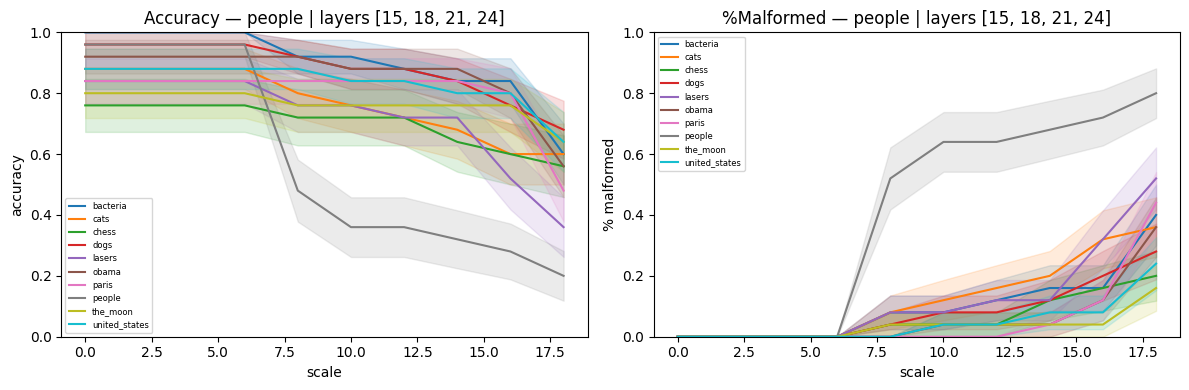

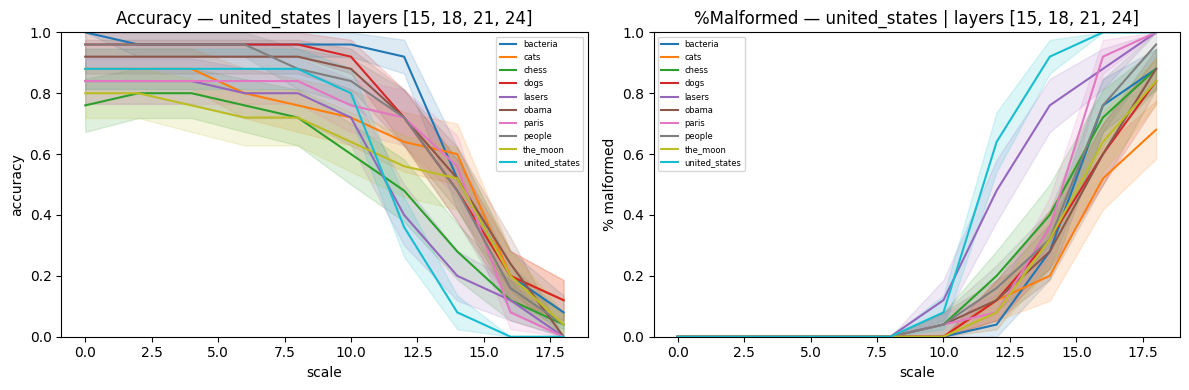

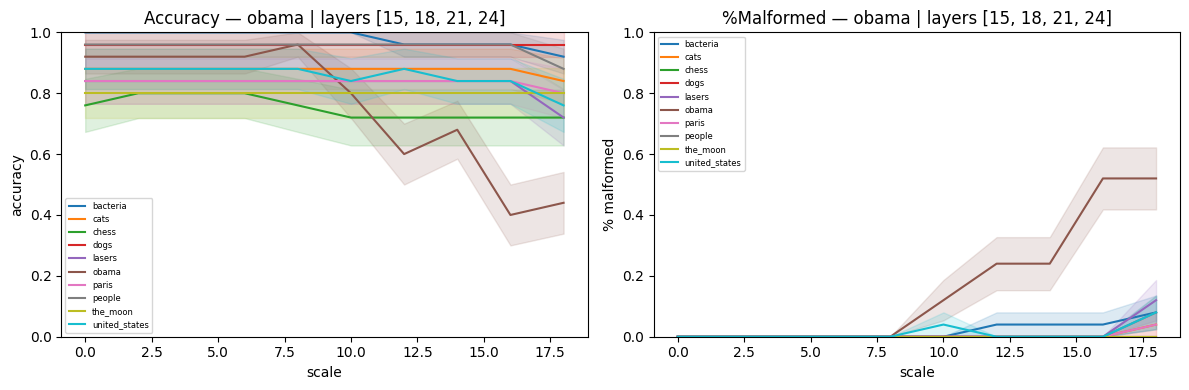

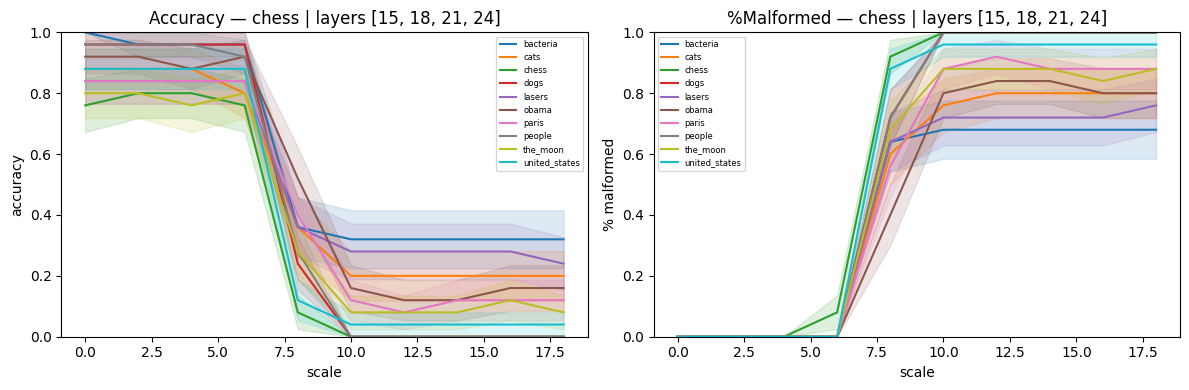

In [18]:
layers = list(range(15, 26, 3))
steered_df = pd.read_csv(STORE / "mcq.csv")
for tgt in targets:
    plot_perf(steered_df[steered_df["target"] == tgt], layers, layers, f"{tgt} | layers {layers}", show_std=True)


# Run QA benchmark. 

In [ ]:
QA_SYSTEM = "Answer the question concisely in one phrase or sentence."

def format_qa_prompt(row):
    return row["q"]

def get_correct_answer(row):
    return row[row["ans"].lower()]

def evaluate_qa_steered(llm, df, target, steer_factory, source_layer=12, target_layer=12, scale=4.0, steer_type="signed"):
    src_layers = _normalize_layers(source_layer)
    tgt_layers = _normalize_layers(target_layer)
    assert len(src_layers) == len(tgt_layers)

    rows = []
    pbar = tqdm(df.iterrows(), total=len(df))
    for _, row in pbar:
        chat = Chat(system_prompt=QA_SYSTEM)
        chat.add_user_message(format_qa_prompt(row))

        llm.reset_all()
        for sl, tl in zip(src_layers, tgt_layers):
            llm.set_steering_op(tl, steer_factory(sl, scale))
        raw = llm.generate_from_chat(chat, max_new_tokens=128, do_sample=False, temperature=1.0)
        llm.reset_all()

        response = trim_to_assistant(raw)
        correct_ans = get_correct_answer(row)
        rows.append({
            "concept": row["concept"],
            "target": target,
            "question": row["q"],
            "correct_answer": correct_ans,
            "scale": scale,
            "source_layer": src_layers if len(src_layers) > 1 else src_layers[0],
            "target_layer": tgt_layers if len(tgt_layers) > 1 else tgt_layers[0],
            "steer_type": steer_type,
            "model_output": response,
        })
        pbar.set_description(f"done {len(rows)}/{len(df)}")
    return pd.DataFrame(rows)

In [ ]:
df_eval = make_set(df_good_val, 25)
targets = ['obama']
scales = np.arange(0, 15, 1).tolist()
source_layers = [list(range(15, 26, 3))]
target_layers = source_layers

all_dfs = []

for tgt_concept in targets:
    factory = signed_steer_factory(v_detect[tgt_concept], v_forget, llm.device)
    for src, tgt in zip(source_layers, target_layers):
        for s in scales:
            df_run = evaluate_qa_steered(
                llm, df_eval, target=tgt_concept, steer_factory=factory,
                source_layer=src, target_layer=tgt,
                scale=s, steer_type="signed",
            )
            all_dfs.append(df_run)

qa_df = pd.concat(all_dfs, ignore_index=True)
qa_df.to_csv(STORE / "qa.csv", index=False)


In [ ]:
qa_df = pd.read_csv(STORE / "qa.csv")

P_correct, R_correct, F_correct = bert_score_fn(
    qa_df["model_output"].tolist(),
    qa_df["correct_answer"].tolist(),
    lang="en", verbose=True,
)
qa_df["bert_sim_correct"] = F_correct.numpy()

idk_refs = ["I don't know."] * len(qa_df)
P_idk, R_idk, F_idk = bert_score_fn(
    qa_df["model_output"].tolist(),
    idk_refs,
    lang="en", verbose=True,
)
qa_df["bert_sim_idk"] = F_idk.numpy()

qa_df.to_csv(STORE / "qa_scored.csv", index=False)


In [ ]:
def plot_qa_perf(qa_df, source_layer, target_layer, label, show_std=False):
    scales = sorted(qa_df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (qa_df["source_layer"].astype(str) == src_str) & (qa_df["target_layer"].astype(str) == tgt_str)

    all_concepts = qa_df["concept"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_concepts)))

    fig, ax = plt.subplots(figsize=(7, 4))
    for color, concept in zip(colors, all_concepts):
        deltas, deltas_sem = [], []
        for s in scales:
            sub = qa_df[mask_layer & (qa_df["scale"] == s) & (qa_df["concept"] == concept)]
            d = sub["bert_sim_correct"] - sub["bert_sim_idk"]
            n = len(d)
            deltas.append(d.mean())
            deltas_sem.append(d.std() / np.sqrt(n) if n > 1 else 0)
        ax.plot(scales, deltas, color=color, label=concept)
        if show_std:
            ax.fill_between(scales, np.array(deltas) - np.array(deltas_sem),
                            np.array(deltas) + np.array(deltas_sem), alpha=0.15, color=color)

    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xlabel("scale")
    ax.set_ylabel("BERTScore F1 (correct − idk)")
    ax.set_title(label)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

In [ ]:
layers = list(range(15, 26, 3))
qa_scored = pd.read_csv(STORE / "qa_scored.csv")
for tgt in qa_scored["target"].unique():
    plot_qa_perf(qa_scored[qa_scored["target"] == tgt], layers, layers, f"{tgt} | layers {layers}", show_std=True)


In [ ]:
IDK_PHRASES = ["i don't know", "i do not know", "i'm not sure", "i cannot answer", "i can't answer", "i don't", "i dont", "i do not"]

def idk_ratio(text):
    text_lower = text.lower()
    for phrase in IDK_PHRASES:
        if phrase in text_lower:
            return len(phrase.split()) / max(len(text_lower.split()), 1)
    return 0.0

def plot_idk(df, source_layer, target_layer, label, show_std=False):
    scales = sorted(df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (df["source_layer"].astype(str) == src_str) & (df["target_layer"].astype(str) == tgt_str)

    all_concepts = df["concept"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_concepts)))

    fig, ax = plt.subplots(figsize=(6, 4))
    for color, concept in zip(colors, all_concepts):
        means, sems = [], []
        for s in scales:
            sub = df[mask_layer & (df["scale"] == s) & (df["concept"] == concept)]
            n = len(sub)
            means.append(sub["idk_ratio"].mean())
            sems.append(sub["idk_ratio"].std() / np.sqrt(n) if n > 1 else 0)
        ax.plot(scales, means, color=color, label=concept)
        if show_std:
            ax.fill_between(scales, np.array(means) - np.array(sems),
                            np.array(means) + np.array(sems), alpha=0.15, color=color)

    ax.set_xlabel("scale"); ax.set_ylabel("IDK ratio")
    ax.set_title(label)
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

In [ ]:
qa_df["idk_ratio"] = qa_df["model_output"].apply(idk_ratio)
plot_idk(qa_df, layers, layers, f"IDK — obama | layers {layers}", show_std=True)

In [ ]:
steered_df = pd.read_csv(STORE / "mcq_ob_good.csv")
steered_df["idk_ratio"] = steered_df["model_output"].apply(idk_ratio)
for tgt in steered_df["target"].unique():
    plot_idk(steered_df[steered_df["target"] == tgt], layers, layers, f"IDK MCQ — {tgt} | layers {layers}", show_std=True)


In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# --- scoring functions ---

def load_perplexity_model(device="cuda"):
    tok = GPT2Tokenizer.from_pretrained("gpt2")
    model = GPT2LMHeadModel.from_pretrained("gpt2").eval().to(device)
    return tok, model

def perplexity(text, tok, model, device="cuda", max_len=512):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=max_len).to(device)
    with torch.no_grad():
        loss = model(**enc, labels=enc["input_ids"]).loss
    return loss.exp().item()

# --- precompute columns ---

tok, ppl_model = load_perplexity_model()

qa_df["perplexity"] = qa_df["model_output"].apply(lambda x: perplexity(x, tok, ppl_model))

def plot_fluency(df, source_layer, target_layer, label, show_std=False):
    scales = sorted(df["scale"].unique())
    src_str, tgt_str = str(source_layer), str(target_layer)
    mask_layer = (df["source_layer"].astype(str) == src_str) & (df["target_layer"].astype(str) == tgt_str)

    all_concepts = df["concept"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_concepts)))

    fig, ax = plt.subplots(figsize=(6, 4))
    for color, concept in zip(colors, all_concepts):
        means, sems = [], []
        for s in scales:
            sub = df[mask_layer & (df["scale"] == s) & (df["concept"] == concept)]
            n = len(sub)
            means.append(sub["perplexity"].mean())
            sems.append(sub["perplexity"].std() / np.sqrt(n) if n > 1 else 0)
        ax.plot(scales, means, color=color, label=concept)
        if show_std:
            ax.fill_between(scales, np.array(means) - np.array(sems),
                            np.array(means) + np.array(sems), alpha=0.15, color=color)

    ax.set_xlabel("scale"); ax.set_ylabel("Perplexity (GPT-2)")
    ax.set_title(label)
    ax.legend(fontsize=7, loc="upper right")
    plt.tight_layout()
    plt.show()


In [ ]:
plot_fluency(qa_df, layers, layers, f"Fluency — obama | layers {layers}", show_std=True)